<a href="https://colab.research.google.com/github/Satwickkk/Tailwyndz_Assessment3_Retail_Forecasting/blob/main/Tailwyndz_Assessment3_Retail_Forecasting_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install catboost openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


# **UPLOAD DATASET**

In [ ]:
from google.colab import files

uploaded = files.upload()

print("Uploaded file:")
print(list(uploaded.keys()))

Saving dunnhumby - Breakfast at the Frat.xlsx to dunnhumby - Breakfast at the Frat (1).xlsx
Uploaded file:
['dunnhumby - Breakfast at the Frat (1).xlsx']


In [ ]:
import io

filename = list(uploaded.keys())[0]

print("Using file:")
print(filename)

Using file:
dunnhumby - Breakfast at the Frat (1).xlsx


# **READ THE THREE DATA TABLES**



In [ ]:
transactions = pd.read_excel(
    io.BytesIO(uploaded[filename]),
    sheet_name="dh Transaction Data",
    header=1
)

stores = pd.read_excel(
    io.BytesIO(uploaded[filename]),
    sheet_name="dh Store Lookup",
    header=1
)

products = pd.read_excel(
    io.BytesIO(uploaded[filename]),
    sheet_name="dh Products Lookup",
    header=1
)

print("Transactions shape:", transactions.shape)
print("Stores shape:", stores.shape)
print("Products shape:", products.shape)

Transactions shape: (524950, 12)
Stores shape: (79, 9)
Products shape: (58, 6)


In [ ]:
print("========== TRANSACTION DATA ==========")
display(transactions.head())

print("\n========== STORE DATA ==========")
display(stores.head())

print("\n========== PRODUCT DATA ==========")
display(products.head())

========== TRANSACTION DATA ==========


,WEEK_END_DATE,STORE_NUM,UPC,UNITS,VISITS,HHS,SPEND,PRICE,BASE_PRICE,FEATURE,DISPLAY,TPR_ONLY
0,2009-01-14,367,1111009477,13,13,13,18.07,1.39,1.57,0,0,1
1,2009-01-14,367,1111009497,20,18,18,27.80,1.39,1.39,0,0,0
2,2009-01-14,367,1111009507,14,14,14,19.32,1.38,1.38,0,0,0
3,2009-01-14,367,1111035398,4,3,3,14.00,3.50,4.49,0,0,1
4,2009-01-14,367,1111038078,3,3,3,7.50,2.50,2.50,0,0,0



========== STORE DATA ==========


,STORE_ID,STORE_NAME,ADDRESS_CITY_NAME,ADDRESS_STATE_PROV_CODE,MSA_CODE,SEG_VALUE_NAME,PARKING_SPACE_QTY,SALES_AREA_SIZE_NUM,AVG_WEEKLY_BASKETS
0,389,SILVERLAKE,ERLANGER,KY,17140,MAINSTREAM,408.0,46073,24766.807692
1,2277,ANDERSON TOWNE CTR,CINCINNATI,OH,17140,UPSCALE,NaN,81958,54052.519231
2,4259,WARSAW AVENUE,CINCINNATI,OH,17140,VALUE,NaN,48813,31177.333333
3,6379,KINGWOOD,KINGWOOD,TX,26420,MAINSTREAM,NaN,50237,20620.423077
4,6431,AT WARD ROAD,BAYTOWN,TX,26420,VALUE,350.0,43698,24321.942308



========== PRODUCT DATA ==========


,UPC,DESCRIPTION,MANUFACTURER,CATEGORY,SUB_CATEGORY,PRODUCT_SIZE
0,1111009477,PL MINI TWIST PRETZELS,PRIVATE LABEL,BAG SNACKS,PRETZELS,15 OZ
1,1111009497,PL PRETZEL STICKS,PRIVATE LABEL,BAG SNACKS,PRETZELS,15 OZ
2,1111009507,PL TWIST PRETZELS,PRIVATE LABEL,BAG SNACKS,PRETZELS,15 OZ
3,1111035398,PL BL MINT ANTSPTC RINSE,PRIVATE LABEL,ORAL HYGIENE PRODUCTS,MOUTHWASHES (ANTISEPTIC),1.5 LT
4,1111038078,PL BL MINT ANTSPTC RINSE,PRIVATE LABEL,ORAL HYGIENE PRODUCTS,MOUTHWASHES (ANTISEPTIC),500 ML


In [ ]:
print("Transaction columns:")
print(transactions.columns.tolist())

print("\nStore columns:")
print(stores.columns.tolist())

print("\nProduct columns:")
print(products.columns.tolist())

Transaction columns:
['WEEK_END_DATE', 'STORE_NUM', 'UPC', 'UNITS', 'VISITS', 'HHS', 'SPEND', 'PRICE', 'BASE_PRICE', 'FEATURE', 'DISPLAY', 'TPR_ONLY']

Store columns:
['STORE_ID', 'STORE_NAME', 'ADDRESS_CITY_NAME', 'ADDRESS_STATE_PROV_CODE', 'MSA_CODE', 'SEG_VALUE_NAME', 'PARKING_SPACE_QTY', 'SALES_AREA_SIZE_NUM', 'AVG_WEEKLY_BASKETS']

Product columns:
['UPC', 'DESCRIPTION', 'MANUFACTURER', 'CATEGORY', 'SUB_CATEGORY', 'PRODUCT_SIZE']


# **CLEAN COLUMN NAMES**

In [ ]:
transactions.columns = (
    transactions.columns
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(" ", "_")
)

stores.columns = (
    stores.columns
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(" ", "_")
)

products.columns = (
    products.columns
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(" ", "_")
)

print("Transaction columns:")
print(transactions.columns.tolist())

print("\nStore columns:")
print(stores.columns.tolist())

print("\nProduct columns:")
print(products.columns.tolist())

Transaction columns:
['WEEK_END_DATE', 'STORE_NUM', 'UPC', 'UNITS', 'VISITS', 'HHS', 'SPEND', 'PRICE', 'BASE_PRICE', 'FEATURE', 'DISPLAY', 'TPR_ONLY']

Store columns:
['STORE_ID', 'STORE_NAME', 'ADDRESS_CITY_NAME', 'ADDRESS_STATE_PROV_CODE', 'MSA_CODE', 'SEG_VALUE_NAME', 'PARKING_SPACE_QTY', 'SALES_AREA_SIZE_NUM', 'AVG_WEEKLY_BASKETS']

Product columns:
['UPC', 'DESCRIPTION', 'MANUFACTURER', 'CATEGORY', 'SUB_CATEGORY', 'PRODUCT_SIZE']


In [ ]:
transactions["WEEK_END_DATE"] = pd.to_datetime(
    transactions["WEEK_END_DATE"],
    errors="coerce"
)

transactions["STORE_NUM"] = pd.to_numeric(
    transactions["STORE_NUM"],
    errors="coerce"
)

transactions["UPC"] = pd.to_numeric(
    transactions["UPC"],
    errors="coerce"
)

stores["STORE_ID"] = pd.to_numeric(
    stores["STORE_ID"],
    errors="coerce"
)

products["UPC"] = pd.to_numeric(
    products["UPC"],
    errors="coerce"
)

print("Data types converted.")

Data types converted.


# **DATA QUALITY ANALYSIS**

In [ ]:
print("TRANSACTION DATA")
transactions.info()

print("\nSTORE DATA")
stores.info()

print("\nPRODUCT DATA")
products.info()

TRANSACTION DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524950 entries, 0 to 524949
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   WEEK_END_DATE  524950 non-null  datetime64[ns]
 1   STORE_NUM      524950 non-null  int64         
 2   UPC            524950 non-null  int64         
 3   UNITS          524950 non-null  int64         
 4   VISITS         524950 non-null  int64         
 5   HHS            524950 non-null  int64         
 6   SPEND          524950 non-null  float64       
 7   PRICE          524927 non-null  float64       
 8   BASE_PRICE     524765 non-null  float64       
 9   FEATURE        524950 non-null  int64         
 10  DISPLAY        524950 non-null  int64         
 11  TPR_ONLY       524950 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 48.1 MB

STORE DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 

In [ ]:
print("TRANSACTION DATA")
transactions.info()

print("\nSTORE DATA")
stores.info()

print("\nPRODUCT DATA")
products.info()

TRANSACTION DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524950 entries, 0 to 524949
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   WEEK_END_DATE  524950 non-null  datetime64[ns]
 1   STORE_NUM      524950 non-null  int64         
 2   UPC            524950 non-null  int64         
 3   UNITS          524950 non-null  int64         
 4   VISITS         524950 non-null  int64         
 5   HHS            524950 non-null  int64         
 6   SPEND          524950 non-null  float64       
 7   PRICE          524927 non-null  float64       
 8   BASE_PRICE     524765 non-null  float64       
 9   FEATURE        524950 non-null  int64         
 10  DISPLAY        524950 non-null  int64         
 11  TPR_ONLY       524950 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 48.1 MB

STORE DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 

In [ ]:
print("========== TRANSACTIONS ==========")
display(
    transactions.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("\n========== STORES ==========")
display(
    stores.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("\n========== PRODUCTS ==========")
display(
    products.isnull()
    .sum()
    .sort_values(ascending=False)
)

========== TRANSACTIONS ==========


,0
BASE_PRICE,185
PRICE,23
WEEK_END_DATE,0
STORE_NUM,0
UNITS,0
UPC,0
HHS,0
VISITS,0
SPEND,0
FEATURE,0



========== STORES ==========


,0
PARKING_SPACE_QTY,52
STORE_ID,0
STORE_NAME,0
ADDRESS_STATE_PROV_CODE,0
ADDRESS_CITY_NAME,0
MSA_CODE,0
SEG_VALUE_NAME,0
SALES_AREA_SIZE_NUM,0
AVG_WEEKLY_BASKETS,0



========== PRODUCTS ==========


,0
UPC,0
DESCRIPTION,0
MANUFACTURER,0
CATEGORY,0
SUB_CATEGORY,0
PRODUCT_SIZE,0


In [ ]:
duplicate_count = transactions.duplicated(
    subset=[
        "WEEK_END_DATE",
        "STORE_NUM",
        "UPC"
    ]
).sum()

print(
    "Duplicate product-store-week records:",
    duplicate_count
)

Duplicate product-store-week records: 0


In [ ]:
duplicates = transactions[
    transactions.duplicated(
        subset=[
            "WEEK_END_DATE",
            "STORE_NUM",
            "UPC"
        ],
        keep=False
    )
]

print("Number of duplicate rows:", len(duplicates))

display(duplicates.head(20))

Number of duplicate rows: 0


,WEEK_END_DATE,STORE_NUM,UPC,UNITS,VISITS,HHS,SPEND,PRICE,BASE_PRICE,FEATURE,DISPLAY,TPR_ONLY


In [ ]:
print(
    "Start date:",
    transactions["WEEK_END_DATE"].min()
)

print(
    "End date:",
    transactions["WEEK_END_DATE"].max()
)

print(
    "Number of unique weeks:",
    transactions["WEEK_END_DATE"].nunique()
)

Start date: 2009-01-14 00:00:00
End date: 2012-01-04 00:00:00
Number of unique weeks: 156


In [ ]:
print(
    "Unique stores:",
    transactions["STORE_NUM"].nunique()
)

print(
    "Unique products:",
    transactions["UPC"].nunique()
)

Unique stores: 77
Unique products: 55


In [ ]:
print("Negative units:",
      (transactions["UNITS"] < 0).sum())

print("Negative price:",
      (transactions["PRICE"] < 0).sum())

print("Negative base price:",
      (transactions["BASE_PRICE"] < 0).sum())

print("Negative spend:",
      (transactions["SPEND"] < 0).sum())

Negative units: 0
Negative price: 0
Negative base price: 0
Negative spend: 0


In [ ]:
print(
    "Zero-unit records:",
    (transactions["UNITS"] == 0).sum()
)

print(
    "Percentage of zero-unit records:",
    round(
        (transactions["UNITS"] == 0).mean() * 100,
        2
    ),
    "%"
)

Zero-unit records: 5
Percentage of zero-unit records: 0.0 %


# **CHECK TABLE RELATIONSHIPS**

In [ ]:
missing_products = set(
    transactions["UPC"].dropna().unique()
) - set(
    products["UPC"].dropna().unique()
)

print(
    "Products missing from product lookup:",
    len(missing_products)
)

if len(missing_products) > 0:
    print(missing_products)

Products missing from product lookup: 0


In [ ]:
missing_stores = set(
    transactions["STORE_NUM"].dropna().unique()
) - set(
    stores["STORE_ID"].dropna().unique()
)

print(
    "Stores missing from store lookup:",
    len(missing_stores)
)

if len(missing_stores) > 0:
    print(missing_stores)

Stores missing from store lookup: 0


# **MERGE THE THREE TABLES**

In [ ]:
df = transactions.merge(
    products,
    on="UPC",
    how="left",
    suffixes=("", "_PRODUCT")
)

print("After product merge:", df.shape)

display(df.head())

After product merge: (524950, 17)


,WEEK_END_DATE,STORE_NUM,UPC,UNITS,VISITS,HHS,SPEND,PRICE,BASE_PRICE,FEATURE,DISPLAY,TPR_ONLY,DESCRIPTION,MANUFACTURER,CATEGORY,SUB_CATEGORY,PRODUCT_SIZE
0,2009-01-14,367,1111009477,13,13,13,18.07,1.39,1.57,0,0,1,PL MINI TWIST PRETZELS,PRIVATE LABEL,BAG SNACKS,PRETZELS,15 OZ
1,2009-01-14,367,1111009497,20,18,18,27.80,1.39,1.39,0,0,0,PL PRETZEL STICKS,PRIVATE LABEL,BAG SNACKS,PRETZELS,15 OZ
2,2009-01-14,367,1111009507,14,14,14,19.32,1.38,1.38,0,0,0,PL TWIST PRETZELS,PRIVATE LABEL,BAG SNACKS,PRETZELS,15 OZ
3,2009-01-14,367,1111035398,4,3,3,14.00,3.50,4.49,0,0,1,PL BL MINT ANTSPTC RINSE,PRIVATE LABEL,ORAL HYGIENE PRODUCTS,MOUTHWASHES (ANTISEPTIC),1.5 LT
4,2009-01-14,367,1111038078,3,3,3,7.50,2.50,2.50,0,0,0,PL BL MINT ANTSPTC RINSE,PRIVATE LABEL,ORAL HYGIENE PRODUCTS,MOUTHWASHES (ANTISEPTIC),500 ML


In [ ]:
df = df.merge(
    stores,
    left_on="STORE_NUM",
    right_on="STORE_ID",
    how="left",
    suffixes=("", "_STORE")
)

print("Final merged dataset:", df.shape)

display(df.head())

Final merged dataset: (538643, 26)


,WEEK_END_DATE,STORE_NUM,UPC,UNITS,VISITS,HHS,SPEND,PRICE,BASE_PRICE,FEATURE,DISPLAY,TPR_ONLY,DESCRIPTION,MANUFACTURER,CATEGORY,SUB_CATEGORY,PRODUCT_SIZE,STORE_ID,STORE_NAME,ADDRESS_CITY_NAME,ADDRESS_STATE_PROV_CODE,MSA_CODE,SEG_VALUE_NAME,PARKING_SPACE_QTY,SALES_AREA_SIZE_NUM,AVG_WEEKLY_BASKETS
0,2009-01-14,367,1111009477,13,13,13,18.07,1.39,1.57,0,0,1,PL MINI TWIST PRETZELS,PRIVATE LABEL,BAG SNACKS,PRETZELS,15 OZ,367,15TH & MADISON,COVINGTON,KY,17140,VALUE,196.0,24721,12706.532051
1,2009-01-14,367,1111009497,20,18,18,27.80,1.39,1.39,0,0,0,PL PRETZEL STICKS,PRIVATE LABEL,BAG SNACKS,PRETZELS,15 OZ,367,15TH & MADISON,COVINGTON,KY,17140,VALUE,196.0,24721,12706.532051
2,2009-01-14,367,1111009507,14,14,14,19.32,1.38,1.38,0,0,0,PL TWIST PRETZELS,PRIVATE LABEL,BAG SNACKS,PRETZELS,15 OZ,367,15TH & MADISON,COVINGTON,KY,17140,VALUE,196.0,24721,12706.532051
3,2009-01-14,367,1111035398,4,3,3,14.00,3.50,4.49,0,0,1,PL BL MINT ANTSPTC RINSE,PRIVATE LABEL,ORAL HYGIENE PRODUCTS,MOUTHWASHES (ANTISEPTIC),1.5 LT,367,15TH & MADISON,COVINGTON,KY,17140,VALUE,196.0,24721,12706.532051
4,2009-01-14,367,1111038078,3,3,3,7.50,2.50,2.50,0,0,0,PL BL MINT ANTSPTC RINSE,PRIVATE LABEL,ORAL HYGIENE PRODUCTS,MOUTHWASHES (ANTISEPTIC),500 ML,367,15TH & MADISON,COVINGTON,KY,17140,VALUE,196.0,24721,12706.532051


In [ ]:
print(df.columns.tolist())

['WEEK_END_DATE', 'STORE_NUM', 'UPC', 'UNITS', 'VISITS', 'HHS', 'SPEND', 'PRICE', 'BASE_PRICE', 'FEATURE', 'DISPLAY', 'TPR_ONLY', 'DESCRIPTION', 'MANUFACTURER', 'CATEGORY', 'SUB_CATEGORY', 'PRODUCT_SIZE', 'STORE_ID', 'STORE_NAME', 'ADDRESS_CITY_NAME', 'ADDRESS_STATE_PROV_CODE', 'MSA_CODE', 'SEG_VALUE_NAME', 'PARKING_SPACE_QTY', 'SALES_AREA_SIZE_NUM', 'AVG_WEEKLY_BASKETS']


In [ ]:
print(
    "Missing product descriptions:",
    df["DESCRIPTION"].isnull().sum()
)

print(
    "Missing store names:",
    df["STORE_NAME"].isnull().sum()
)

Missing product descriptions: 0
Missing store names: 0


# **FEATURE ENGINEERING: PRICE**

In [ ]:
df["DISCOUNT_PCT"] = np.where(
    df["BASE_PRICE"] > 0,
    (
        (df["BASE_PRICE"] - df["PRICE"])
        / df["BASE_PRICE"]
    ),
    0
)

df["DISCOUNT_PCT"] = df["DISCOUNT_PCT"].clip(
    lower=0
)

display(
    df[
        [
            "PRICE",
            "BASE_PRICE",
            "DISCOUNT_PCT"
        ]
    ].head(20)
)

,PRICE,BASE_PRICE,DISCOUNT_PCT
0,1.39,1.57,0.114650
1,1.39,1.39,0.000000
2,1.38,1.38,0.000000
3,3.50,4.49,0.220490
4,2.50,2.50,0.000000
5,2.59,2.59,0.000000
6,1.88,1.88,0.000000
7,1.88,1.88,0.000000
8,1.98,1.98,0.000000
9,3.36,3.94,0.147208


# **PROMOTION FEATURES**

In [ ]:
df["ANY_PROMOTION"] = (
    (df["FEATURE"] == 1) |
    (df["DISPLAY"] == 1) |
    (df["TPR_ONLY"] == 1)
).astype(int)

df["PROMOTION_COUNT"] = (
    df["FEATURE"].fillna(0) +
    df["DISPLAY"].fillna(0) +
    df["TPR_ONLY"].fillna(0)
)

display(
    df[
        [
            "FEATURE",
            "DISPLAY",
            "TPR_ONLY",
            "ANY_PROMOTION",
            "PROMOTION_COUNT"
        ]
    ].head(20)
)

,FEATURE,DISPLAY,TPR_ONLY,ANY_PROMOTION,PROMOTION_COUNT
0,0,0,1,1,1
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,1,1,1
4,0,0,0,0,0
5,0,0,0,0,0
6,0,0,0,0,0
7,0,0,0,0,0
8,0,0,0,0,0
9,0,1,0,1,1


# **EXPLORATORY DATA ANALYSIS**

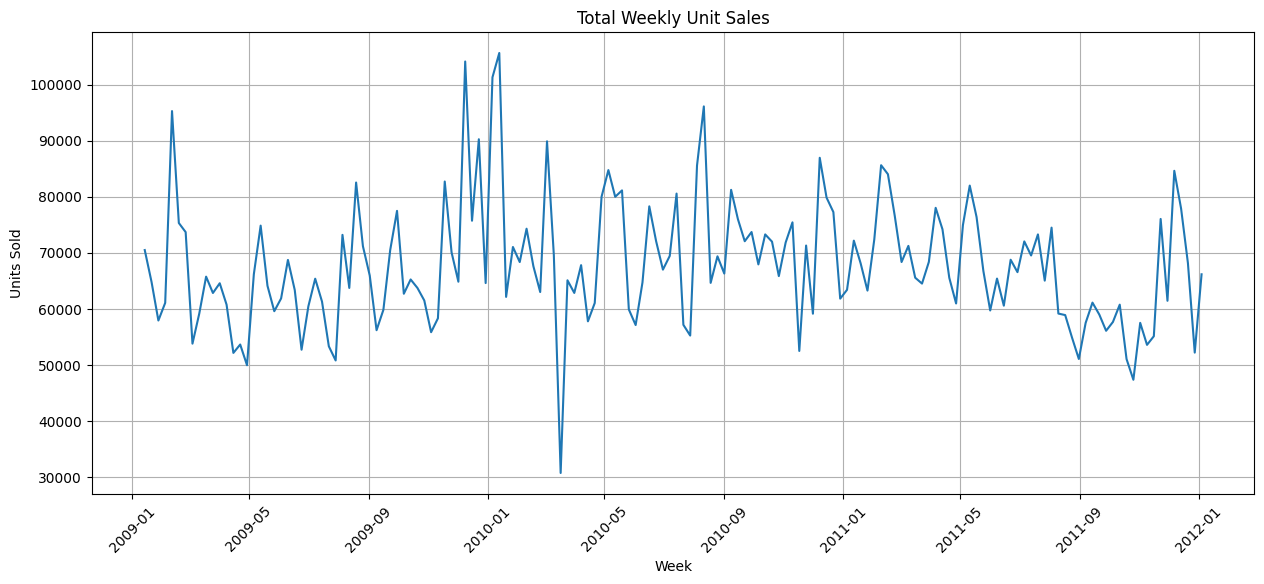

In [ ]:
weekly_sales = (
    df.groupby("WEEK_END_DATE")["UNITS"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(15, 6))

plt.plot(
    weekly_sales["WEEK_END_DATE"],
    weekly_sales["UNITS"]
)

plt.title("Total Weekly Unit Sales")
plt.xlabel("Week")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

,UNITS
CATEGORY,
COLD CEREAL,5979204
BAG SNACKS,2672565
FROZEN PIZZA,1383631
ORAL HYGIENE PRODUCTS,534590


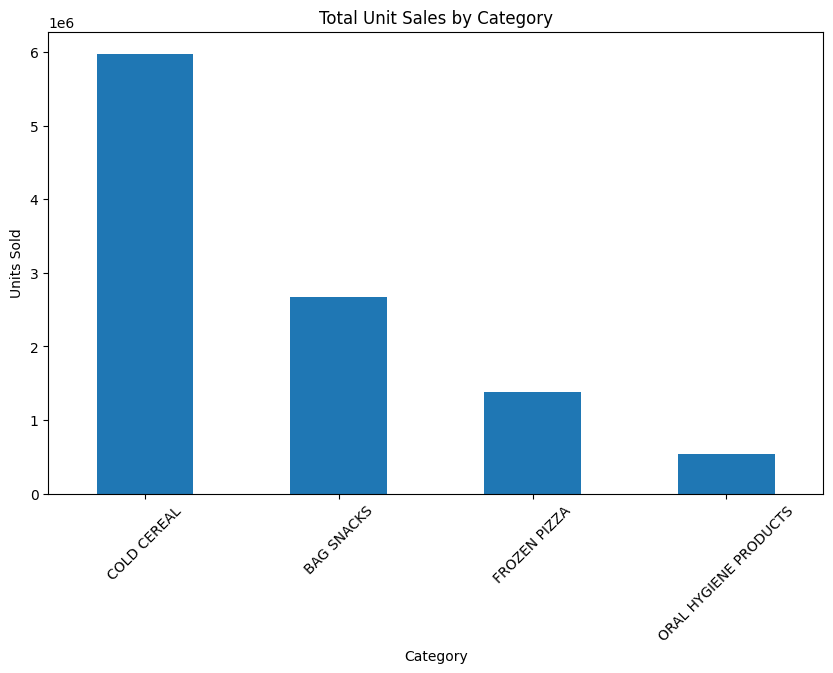

In [ ]:
category_sales = (
    df.groupby("CATEGORY")["UNITS"]
    .sum()
    .sort_values(ascending=False)
)

display(category_sales)

plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Total Unit Sales by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)

plt.show()

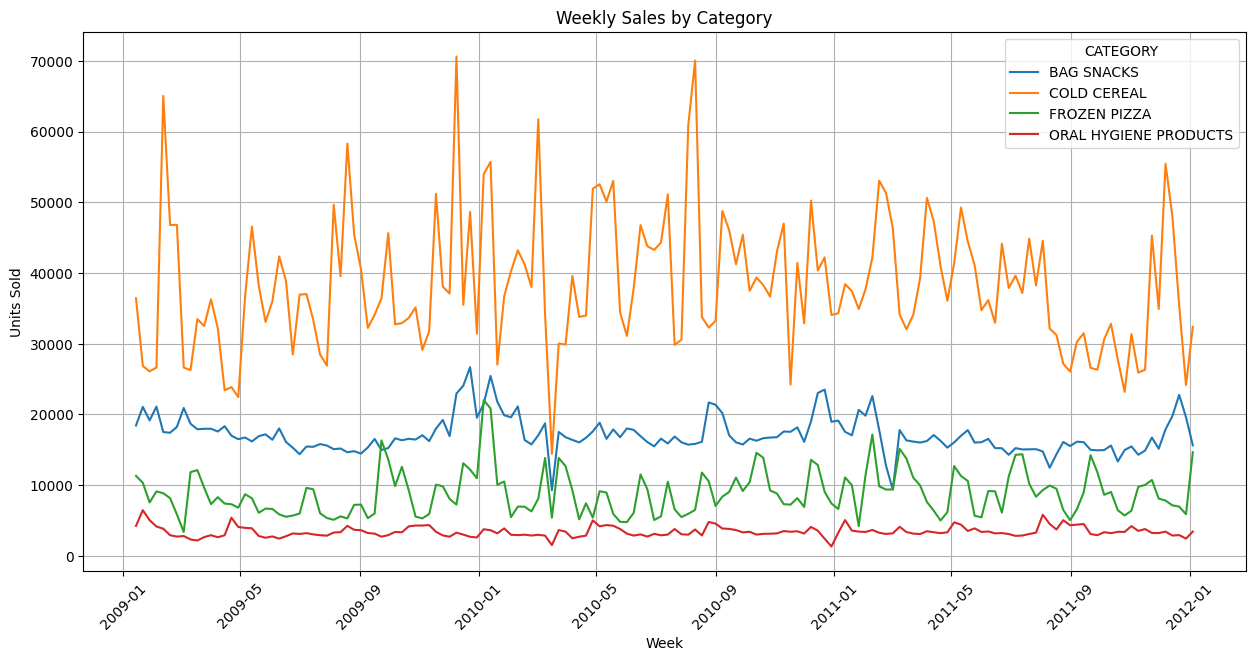

In [ ]:
category_weekly = (
    df.groupby(
        ["WEEK_END_DATE", "CATEGORY"]
    )["UNITS"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=category_weekly,
    x="WEEK_END_DATE",
    y="UNITS",
    hue="CATEGORY"
)

plt.title("Weekly Sales by Category")
plt.xlabel("Week")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
store_sales = (
    df.groupby(
        ["STORE_NUM", "STORE_NAME"]
    )["UNITS"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 15 stores:")
display(store_sales.head(15))

Top 15 stores:


,,UNITS
STORE_NUM,STORE_NAME,
2277,ANDERSON TOWNE CTR,362386
25027,CINCINNATI,344913
4503,ROCKWALL,314600
24991,HYDE PARK,287722
2281,BLUE ASH,268379
9825,DENT,267803
21227,LIBERTY TWP,245339
17627,FLOWER MOUND,238672
389,SILVERLAKE,237272


# **PRICE & PROMOTION ANALYSIS**

In [ ]:
promotion_analysis = (
    df.groupby("ANY_PROMOTION")["UNITS"]
    .agg(
        ["mean", "median", "sum", "count"]
    )
)

display(promotion_analysis)

,mean,median,sum,count
ANY_PROMOTION,,,,
0,15.145416,9.0,5841799,385714
1,30.917557,16.0,4728191,152929


In [ ]:
feature_analysis = (
    df.groupby("FEATURE")["UNITS"]
    .agg(["mean", "median", "count"])
)

display(feature_analysis)

,mean,median,count
FEATURE,,,
0,16.884539,10.0,493145
1,49.309069,27.0,45498


In [ ]:
display_analysis = (
    df.groupby("DISPLAY")["UNITS"]
    .agg(["mean", "median", "count"])
)

display(display_analysis)

,mean,median,count
DISPLAY,,,
0,16.394418,9.0,479189
1,45.648148,27.0,59454


In [ ]:
tpr_analysis = (
    df.groupby("TPR_ONLY")["UNITS"]
    .agg(["mean", "median", "count"])
)

display(tpr_analysis)

,mean,median,count
TPR_ONLY,,,
0,19.907984,11.0,466550
1,17.781477,10.0,72093


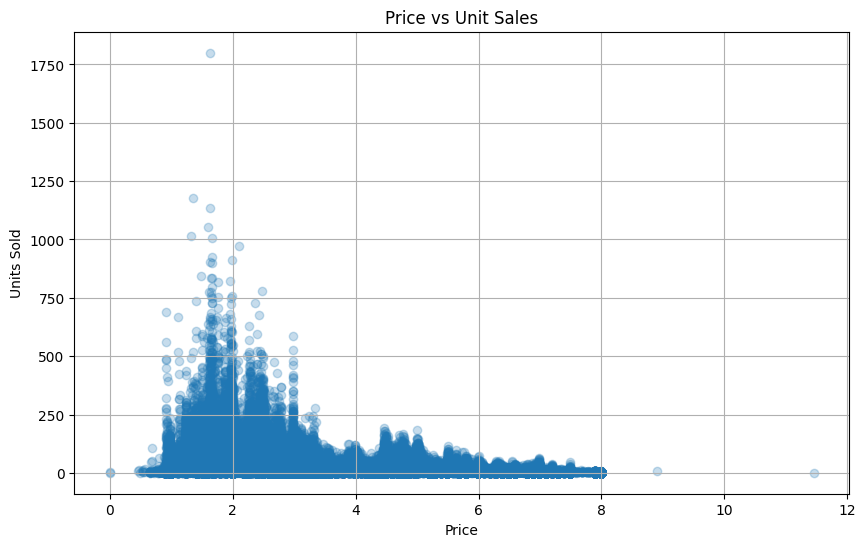

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["PRICE"],
    df["UNITS"],
    alpha=0.25
)

plt.title("Price vs Unit Sales")
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.grid(True)

plt.show()

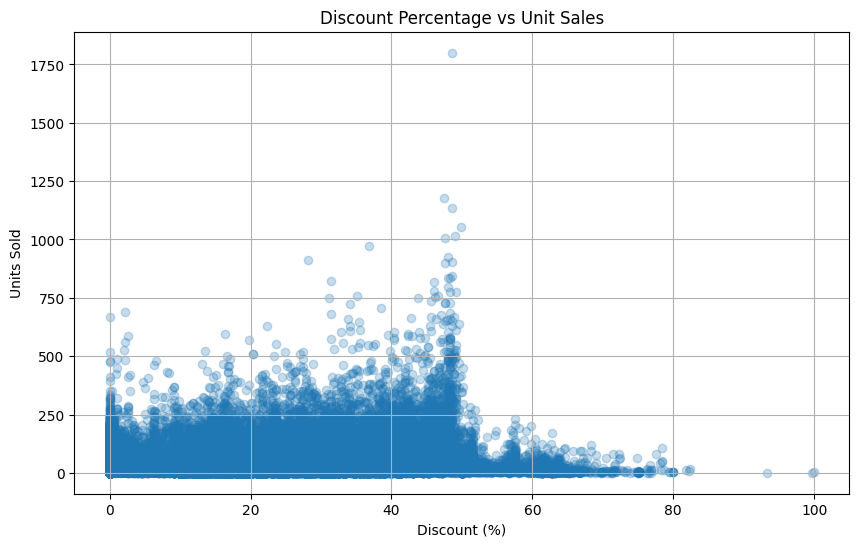

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["DISCOUNT_PCT"] * 100,
    df["UNITS"],
    alpha=0.25
)

plt.title("Discount Percentage vs Unit Sales")
plt.xlabel("Discount (%)")
plt.ylabel("Units Sold")
plt.grid(True)

plt.show()

# **FORECASTING DATA PREPARATION**

In [ ]:
df = df.sort_values(
    [
        "STORE_NUM",
        "UPC",
        "WEEK_END_DATE"
    ]
).reset_index(drop=True)

print("Data sorted successfully.")

Data sorted successfully.


# **LAG FEATURES**

In [ ]:
group_cols = [
    "STORE_NUM",
    "UPC"
]

for lag in [1, 2, 4, 8, 13]:

    df[f"LAG_{lag}"] = (
        df.groupby(group_cols)["UNITS"]
        .shift(lag)
    )

print(
    df[
        [
            "STORE_NUM",
            "UPC",
            "WEEK_END_DATE",
            "UNITS",
            "LAG_1",
            "LAG_2",
            "LAG_4",
            "LAG_8",
            "LAG_13"
        ]
    ].head(20)
)

    STORE_NUM         UPC WEEK_END_DATE  UNITS  LAG_1  LAG_2  LAG_4  LAG_8  \
0         367  1111009477    2009-01-14     13    NaN    NaN    NaN    NaN   
1         367  1111009477    2009-01-21     24   13.0    NaN    NaN    NaN   
2         367  1111009477    2009-01-28      7   24.0   13.0    NaN    NaN   
3         367  1111009477    2009-02-04     12    7.0   24.0    NaN    NaN   
4         367  1111009477    2009-02-11     16   12.0    7.0   13.0    NaN   
5         367  1111009477    2009-02-18     21   16.0   12.0   24.0    NaN   
6         367  1111009477    2009-02-25     11   21.0   16.0    7.0    NaN   
7         367  1111009477    2009-03-04     10   11.0   21.0   12.0    NaN   
8         367  1111009477    2009-03-11     13   10.0   11.0   16.0   13.0   
9         367  1111009477    2009-03-18     13   13.0   10.0   21.0   24.0   
10        367  1111009477    2009-03-25     18   13.0   13.0   11.0    7.0   
11        367  1111009477    2009-04-01     14   18.0   13.0   1

# **ROLLING FEATURES**

In [ ]:
df["ROLLING_MEAN_4"] = (
    df.groupby(group_cols)["UNITS"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(4)
        .mean()
    )
)

df["ROLLING_MEAN_8"] = (
    df.groupby(group_cols)["UNITS"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(8)
        .mean()
    )
)

df["ROLLING_MEAN_13"] = (
    df.groupby(group_cols)["UNITS"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(13)
        .mean()
    )
)

In [ ]:
df["ROLLING_STD_4"] = (
    df.groupby(group_cols)["UNITS"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(4)
        .std()
    )
)

display(
    df[
        [
            "UNITS",
            "LAG_1",
            "LAG_4",
            "ROLLING_MEAN_4",
            "ROLLING_MEAN_13",
            "ROLLING_STD_4"
        ]
    ].head(20)
)

,UNITS,LAG_1,LAG_4,ROLLING_MEAN_4,ROLLING_MEAN_13,ROLLING_STD_4
0,13,NaN,NaN,NaN,NaN,NaN
1,24,13.0,NaN,NaN,NaN,NaN
2,7,24.0,NaN,NaN,NaN,NaN
3,12,7.0,NaN,NaN,NaN,NaN
4,16,12.0,13.0,14.00,NaN,7.164728
5,21,16.0,24.0,14.75,NaN,7.182154
6,11,21.0,7.0,14.00,NaN,5.944185
7,10,11.0,12.0,15.00,NaN,4.546061
8,13,10.0,16.0,14.50,NaN,5.066228
9,13,13.0,21.0,13.75,NaN,4.991660


# **CALENDAR FEATURES**

In [ ]:
df["YEAR"] = (
    df["WEEK_END_DATE"].dt.year
)

df["MONTH"] = (
    df["WEEK_END_DATE"].dt.month
)

df["QUARTER"] = (
    df["WEEK_END_DATE"].dt.quarter
)

df["WEEK_OF_YEAR"] = (
    df["WEEK_END_DATE"]
    .dt.isocalendar()
    .week
    .astype(int)
)

display(
    df[
        [
            "WEEK_END_DATE",
            "YEAR",
            "MONTH",
            "QUARTER",
            "WEEK_OF_YEAR"
        ]
    ].head()
)

,WEEK_END_DATE,YEAR,MONTH,QUARTER,WEEK_OF_YEAR
0,2009-01-14,2009,1,1,3
1,2009-01-21,2009,1,1,4
2,2009-01-28,2009,1,1,5
3,2009-02-04,2009,2,1,6
4,2009-02-11,2009,2,1,7


In [ ]:
df["WEEK_SIN"] = np.sin(
    2 * np.pi *
    df["WEEK_OF_YEAR"] / 52
)

df["WEEK_COS"] = np.cos(
    2 * np.pi *
    df["WEEK_OF_YEAR"] / 52
)

# **CREATE MODELING DATASET**

In [ ]:
required_lag_columns = [
    "LAG_1",
    "LAG_2",
    "LAG_4",
    "LAG_8",
    "LAG_13",
    "ROLLING_MEAN_4",
    "ROLLING_MEAN_8",
    "ROLLING_MEAN_13"
]

df_model = df.dropna(
    subset=required_lag_columns
).copy()

print("Original rows:", len(df))
print("Model rows:", len(df_model))

Original rows: 538643
Model rows: 488229


In [ ]:
display(
    df_model[
        [
            "WEEK_END_DATE",
            "STORE_NUM",
            "UPC",
            "UNITS",
            "LAG_1",
            "LAG_4",
            "LAG_13",
            "ROLLING_MEAN_4",
            "PRICE",
            "DISCOUNT_PCT",
            "FEATURE",
            "DISPLAY",
            "TPR_ONLY"
        ]
    ].head(20)
)

,WEEK_END_DATE,STORE_NUM,UPC,UNITS,LAG_1,LAG_4,LAG_13,ROLLING_MEAN_4,PRICE,DISCOUNT_PCT,FEATURE,DISPLAY,TPR_ONLY
13,2009-04-15,367,1111009477,10,5.0,13.0,13.0,12.50,1.46,0.000000,0,0,0
14,2009-04-22,367,1111009477,27,10.0,18.0,24.0,11.75,1.21,0.171233,0,0,1
15,2009-04-29,367,1111009477,5,27.0,14.0,7.0,14.00,1.21,0.171233,0,0,1
16,2009-05-06,367,1111009477,20,5.0,5.0,12.0,11.75,1.24,0.150685,0,0,1
17,2009-05-13,367,1111009477,26,20.0,10.0,16.0,15.50,1.24,0.150685,0,0,1
18,2009-05-20,367,1111009477,18,26.0,27.0,21.0,19.50,1.24,0.150685,0,0,1
19,2009-05-27,367,1111009477,14,18.0,5.0,11.0,17.25,1.24,0.150685,0,0,1
20,2009-06-03,367,1111009477,10,14.0,20.0,10.0,19.50,1.22,0.000000,0,0,0
21,2009-06-10,367,1111009477,22,10.0,26.0,13.0,17.00,1.25,0.000000,0,0,0
22,2009-06-17,367,1111009477,14,22.0,18.0,13.0,16.00,1.65,0.000000,0,0,0


# **13-WEEK TIME SPLIT**

In [ ]:
unique_dates = sorted(
    df_model["WEEK_END_DATE"]
    .dropna()
    .unique()
)

test_dates = unique_dates[-13:]

train_dates = unique_dates[:-13]

print("Training weeks:", len(train_dates))
print("Testing weeks:", len(test_dates))

print(
    "\nTraining period:",
    train_dates[0],
    "to",
    train_dates[-1]
)

print(
    "Testing period:",
    test_dates[0],
    "to",
    test_dates[-1]
)

Training weeks: 137
Testing weeks: 13

Training period: 2009-02-25 00:00:00 to 2011-10-05 00:00:00
Testing period: 2011-10-12 00:00:00 to 2012-01-04 00:00:00


In [ ]:
train = df_model[
    df_model["WEEK_END_DATE"]
    .isin(train_dates)
].copy()

test = df_model[
    df_model["WEEK_END_DATE"]
    .isin(test_dates)
].copy()

print("Training rows:", len(train))
print("Testing rows:", len(test))

Training rows: 444545
Testing rows: 43684


In [ ]:
target = "UNITS"

features = [
    # Store/Product
    "STORE_NUM",
    "UPC",

    # Historical sales
    "LAG_1",
    "LAG_2",
    "LAG_4",
    "LAG_8",
    "LAG_13",

    # Rolling features
    "ROLLING_MEAN_4",
    "ROLLING_MEAN_8",
    "ROLLING_MEAN_13",
    "ROLLING_STD_4",

    # Price
    "PRICE",
    "BASE_PRICE",
    "DISCOUNT_PCT",

    # Promotion
    "FEATURE",
    "DISPLAY",
    "TPR_ONLY",
    "ANY_PROMOTION",
    "PROMOTION_COUNT",

    # Store characteristics
    "SALES_AREA_SIZE_NUM",
    "AVG_WEEKLY_BASKETS",

    # Calendar
    "YEAR",
    "MONTH",
    "QUARTER",
    "WEEK_OF_YEAR",
    "WEEK_SIN",
    "WEEK_COS",

    # Product characteristics
    "MANUFACTURER",
    "CATEGORY",
    "SUB_CATEGORY",
    "PRODUCT_SIZE",

    # Store segment
    "SEG_VALUE_NAME"
]

# Keep only columns that actually exist
features = [
    col for col in features
    if col in train.columns
]

print("Number of features:", len(features))
print(features)

Number of features: 32
['STORE_NUM', 'UPC', 'LAG_1', 'LAG_2', 'LAG_4', 'LAG_8', 'LAG_13', 'ROLLING_MEAN_4', 'ROLLING_MEAN_8', 'ROLLING_MEAN_13', 'ROLLING_STD_4', 'PRICE', 'BASE_PRICE', 'DISCOUNT_PCT', 'FEATURE', 'DISPLAY', 'TPR_ONLY', 'ANY_PROMOTION', 'PROMOTION_COUNT', 'SALES_AREA_SIZE_NUM', 'AVG_WEEKLY_BASKETS', 'YEAR', 'MONTH', 'QUARTER', 'WEEK_OF_YEAR', 'WEEK_SIN', 'WEEK_COS', 'MANUFACTURER', 'CATEGORY', 'SUB_CATEGORY', 'PRODUCT_SIZE', 'SEG_VALUE_NAME']


In [ ]:
categorical_features = [
    col for col in [
        "STORE_NUM",
        "UPC",
        "MANUFACTURER",
        "CATEGORY",
        "SUB_CATEGORY",
        "PRODUCT_SIZE",
        "SEG_VALUE_NAME"
    ]
    if col in features
]

print("Categorical features:")
print(categorical_features)

Categorical features:
['STORE_NUM', 'UPC', 'MANUFACTURER', 'CATEGORY', 'SUB_CATEGORY', 'PRODUCT_SIZE', 'SEG_VALUE_NAME']


In [ ]:
X_train = train[features].copy()
y_train = train[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

for col in categorical_features:

    X_train[col] = (
        X_train[col]
        .fillna("UNKNOWN")
        .astype(str)
    )

    X_test[col] = (
        X_test[col]
        .fillna("UNKNOWN")
        .astype(str)
    )

numeric_features = [
    col for col in features
    if col not in categorical_features
]

for col in numeric_features:

    median_value = X_train[col].median()

    X_train[col] = (
        X_train[col]
        .fillna(median_value)
    )

    X_test[col] = (
        X_test[col]
        .fillna(median_value)
    )

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (444545, 32)
X_test: (43684, 32)


# **BASELINE MODEL**

In [ ]:
baseline_predictions = (
    test["ROLLING_MEAN_4"]
    .values
)

baseline_predictions = np.maximum(
    baseline_predictions,
    0
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_wmape = (
    np.sum(
        np.abs(
            y_test.values -
            baseline_predictions
        )
    )
    /
    np.sum(
        np.abs(y_test.values)
    )
)

print("BASELINE MODEL")
print("----------------------")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("WMAPE:", baseline_wmape)
print("WMAPE %:", baseline_wmape * 100)

BASELINE MODEL
----------------------
MAE: 8.211164270671183
RMSE: 22.059223515192347
WMAPE: 0.4421261458475852
WMAPE %: 44.21261458475852


# **CATBOOST FORECASTING MODEL**

In [ ]:
model = CatBoostRegressor(
    iterations=700,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=80
)

0:	learn: 27.9653678	test: 30.1111451	best: 30.1111451 (0)	total: 824ms	remaining: 9m 35s
100:	learn: 12.1277529	test: 12.1606555	best: 12.1606555 (100)	total: 1m 3s	remaining: 6m 14s
200:	learn: 10.9670555	test: 11.3956160	best: 11.3956160 (200)	total: 2m 7s	remaining: 5m 17s
300:	learn: 10.3303933	test: 11.2205847	best: 11.2195129 (293)	total: 3m 10s	remaining: 4m 12s
400:	learn: 9.8821233	test: 11.0872797	best: 11.0834679 (399)	total: 4m 11s	remaining: 3m 7s
500:	learn: 9.5507611	test: 11.0242696	best: 10.9986130 (478)	total: 5m 13s	remaining: 2m 4s
600:	learn: 9.2780535	test: 10.9174440	best: 10.9174440 (600)	total: 6m 13s	remaining: 1m 1s
699:	learn: 9.0296023	test: 10.9547348	best: 10.9112710 (619)	total: 7m 16s	remaining: 0us

bestTest = 10.91127096
bestIteration = 619

Shrink model to first 620 iterations.


CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=700, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

# **PREDICTIONS**

In [ ]:
predictions = model.predict(X_test)

predictions = np.maximum(
    predictions,
    0
)

print("Predictions generated.")

Predictions generated.


# **MODEL EVALUATION**

In [ ]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

wmape = (
    np.sum(
        np.abs(
            y_test.values -
            predictions
        )
    )
    /
    np.sum(
        np.abs(y_test.values)
    )
)

print("CATBOOST MODEL")
print("----------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("WMAPE:", wmape)
print("WMAPE %:", wmape * 100)

CATBOOST MODEL
----------------------
MAE: 5.106924569832446
RMSE: 10.91118340282982
R²: 0.877127559352307
WMAPE: 0.27497986920797457
WMAPE %: 27.49798692079746


# **MODEL COMPARISON**

In [ ]:
model_comparison = pd.DataFrame({

    "Model": [
        "4-Week Moving Average",
        "CatBoost"
    ],

    "MAE": [
        baseline_mae,
        mae
    ],

    "RMSE": [
        baseline_rmse,
        rmse
    ],

    "WMAPE": [
        baseline_wmape,
        wmape
    ]
})

display(model_comparison)

,Model,MAE,RMSE,WMAPE
0,4-Week Moving Average,8.211164,22.059224,0.442126
1,CatBoost,5.106925,10.911183,0.274980


In [ ]:
comparison = test[
    [
        "WEEK_END_DATE",
        "STORE_NUM",
        "UPC",
        "UNITS"
    ]
].copy()

comparison["PREDICTED_UNITS"] = predictions

comparison["ERROR"] = (
    comparison["UNITS"]
    -
    comparison["PREDICTED_UNITS"]
)

comparison["ABS_ERROR"] = (
    comparison["ERROR"]
    .abs()
)

display(comparison.head(20))

,WEEK_END_DATE,STORE_NUM,UPC,UNITS,PREDICTED_UNITS,ERROR,ABS_ERROR
143,2011-10-12,367,1111009477,12,11.874391,0.125609,0.125609
144,2011-10-19,367,1111009477,9,11.344702,-2.344702,2.344702
145,2011-10-26,367,1111009477,10,10.146261,-0.146261,0.146261
146,2011-11-02,367,1111009477,15,10.208222,4.791778,4.791778
147,2011-11-16,367,1111009477,13,13.045929,-0.045929,0.045929
148,2011-11-23,367,1111009477,22,11.806124,10.193876,10.193876
149,2011-11-30,367,1111009477,10,14.405275,-4.405275,4.405275
150,2011-12-07,367,1111009477,21,13.357108,7.642892,7.642892
151,2011-12-14,367,1111009477,20,17.797918,2.202082,2.202082
152,2011-12-21,367,1111009477,20,19.903445,0.096555,0.096555


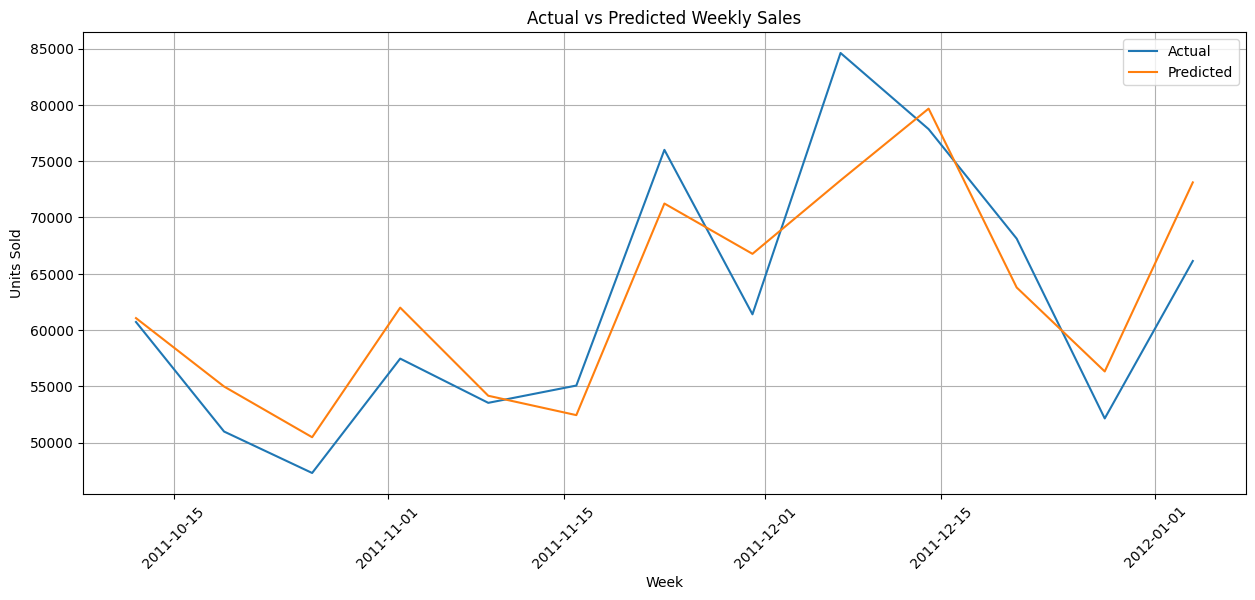

In [ ]:
weekly_comparison = (
    comparison
    .groupby("WEEK_END_DATE")
    .agg(
        Actual=("UNITS", "sum"),
        Predicted=("PREDICTED_UNITS", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(15, 6))

plt.plot(
    weekly_comparison["WEEK_END_DATE"],
    weekly_comparison["Actual"],
    label="Actual"
)

plt.plot(
    weekly_comparison["WEEK_END_DATE"],
    weekly_comparison["Predicted"],
    label="Predicted"
)

plt.title(
    "Actual vs Predicted Weekly Sales"
)

plt.xlabel("Week")
plt.ylabel("Units Sold")

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [ ]:
importance = pd.DataFrame({

    "Feature": features,

    "Importance":
        model.get_feature_importance()
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(
    importance.head(20)
)

,Feature,Importance
14,FEATURE,16.992841
9,ROLLING_MEAN_13,15.194891
13,DISCOUNT_PCT,11.067323
2,LAG_1,9.230715
11,PRICE,5.360678
27,MANUFACTURER,5.076699
15,DISPLAY,2.922055
24,WEEK_OF_YEAR,2.262353
29,SUB_CATEGORY,2.168526
25,WEEK_SIN,2.021376


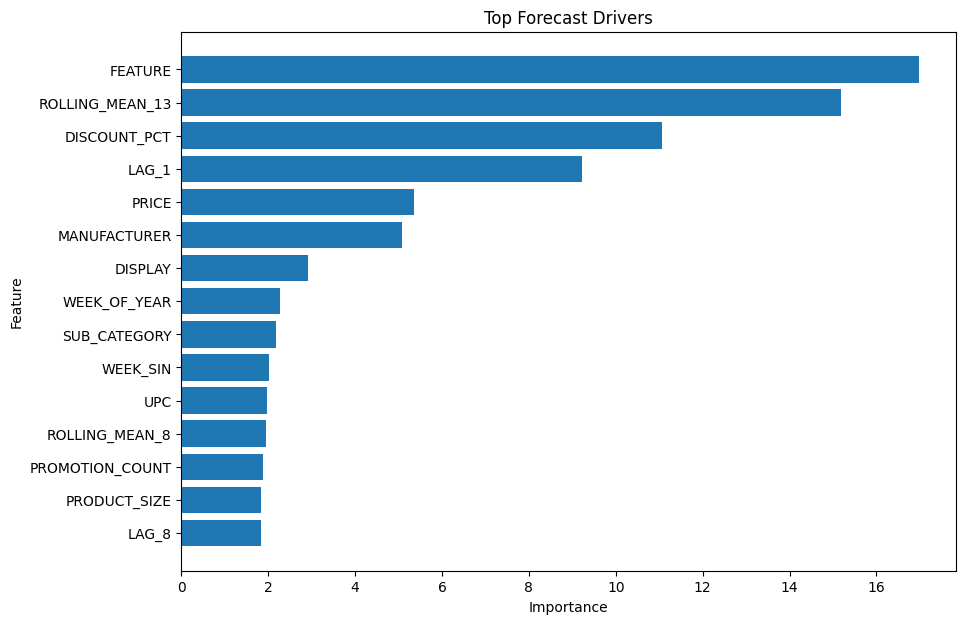

In [ ]:
top_features = importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title(
    "Top Forecast Drivers"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# **ABLATION STUDY**

In [ ]:
historical_features = [
    "LAG_1",
    "LAG_2",
    "LAG_4",
    "LAG_8",
    "LAG_13",
    "ROLLING_MEAN_4",
    "ROLLING_MEAN_8",
    "ROLLING_MEAN_13",
    "ROLLING_STD_4"
]

price_features = [
    "PRICE",
    "BASE_PRICE",
    "DISCOUNT_PCT"
]

promotion_features = [
    "FEATURE",
    "DISPLAY",
    "TPR_ONLY",
    "ANY_PROMOTION",
    "PROMOTION_COUNT"
]

In [ ]:
def train_evaluate_ablation(
    feature_list,
    model_name
):

    feature_list = [
        f for f in feature_list
        if f in X_train.columns
    ]

    Xtr = X_train[
        feature_list
    ].copy()

    Xte = X_test[
        feature_list
    ].copy()

    cats = [
        c for c in categorical_features
        if c in feature_list
    ]

    temp_model = CatBoostRegressor(
        iterations=400,
        depth=7,
        learning_rate=0.05,
        loss_function="RMSE",
        random_seed=42,
        verbose=False
    )

    temp_model.fit(
        Xtr,
        y_train,
        cat_features=cats
    )

    pred = temp_model.predict(
        Xte
    )

    pred = np.maximum(
        pred,
        0
    )

    mae_value = mean_absolute_error(
        y_test,
        pred
    )

    rmse_value = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    wmape_value = (
        np.sum(
            np.abs(
                y_test.values -
                pred
            )
        )
        /
        np.sum(
            np.abs(y_test.values)
        )
    )

    return {
        "Model": model_name,
        "MAE": mae_value,
        "RMSE": rmse_value,
        "WMAPE": wmape_value
    }

In [ ]:
ablation_results = []

ablation_results.append(
    train_evaluate_ablation(
        historical_features,
        "Historical Sales Only"
    )
)

ablation_results.append(
    train_evaluate_ablation(
        historical_features +
        price_features,
        "Sales + Price"
    )
)

ablation_results.append(
    train_evaluate_ablation(
        historical_features +
        price_features +
        promotion_features,
        "Sales + Price + Promotion"
    )
)

ablation_results.append(
    train_evaluate_ablation(
        features,
        "Full Model"
    )
)

ablation_results = pd.DataFrame(
    ablation_results
)

display(ablation_results)

,Model,MAE,RMSE,WMAPE
0,Historical Sales Only,7.105184,19.904561,0.382575
1,Sales + Price,5.907876,15.091187,0.318107
2,Sales + Price + Promotion,5.397217,12.693982,0.290611
3,Full Model,5.174430,11.075046,0.278615


# **PROMOTION ANALYSIS**

In [ ]:
promotion_effect = (
    df.groupby("ANY_PROMOTION")
    .agg(
        Average_Units=("UNITS", "mean"),
        Median_Units=("UNITS", "median"),
        Total_Units=("UNITS", "sum"),
        Observations=("UNITS", "count")
    )
    .reset_index()
)

display(promotion_effect)

,ANY_PROMOTION,Average_Units,Median_Units,Total_Units,Observations
0,0,15.145416,9.0,5841799,385714
1,1,30.917557,16.0,4728191,152929


In [ ]:
no_promo = promotion_effect.loc[
    promotion_effect["ANY_PROMOTION"] == 0,
    "Average_Units"
].iloc[0]

promo = promotion_effect.loc[
    promotion_effect["ANY_PROMOTION"] == 1,
    "Average_Units"
].iloc[0]

promotion_uplift = (
    (promo - no_promo)
    /
    no_promo
)

print(
    "Observed promotion uplift:",
    round(
        promotion_uplift * 100,
        2
    ),
    "%"
)

Observed promotion uplift: 104.14 %


# **PROMOTION BY CATEGORY**

In [ ]:
category_promotion = (
    df.groupby(
        [
            "CATEGORY",
            "ANY_PROMOTION"
        ]
    )["UNITS"]
    .mean()
    .reset_index()
)

display(category_promotion)

,CATEGORY,ANY_PROMOTION,UNITS
0,BAG SNACKS,0,16.864071
1,BAG SNACKS,1,28.893559
2,COLD CEREAL,0,25.514517
3,COLD CEREAL,1,62.897544
4,FROZEN PIZZA,0,7.939616
5,FROZEN PIZZA,1,21.540641
6,ORAL HYGIENE PRODUCTS,0,3.503181
7,ORAL HYGIENE PRODUCTS,1,6.579513


In [ ]:
pivot_promotion = category_promotion.pivot(
    index="CATEGORY",
    columns="ANY_PROMOTION",
    values="UNITS"
)

pivot_promotion.columns = [
    "No_Promotion",
    "Promotion"
]

pivot_promotion["Uplift_%"] = (
    (
        pivot_promotion["Promotion"]
        -
        pivot_promotion["No_Promotion"]
    )
    /
    pivot_promotion["No_Promotion"]
) * 100

display(
    pivot_promotion.sort_values(
        "Uplift_%",
        ascending=False
    )
)

,No_Promotion,Promotion,Uplift_%
CATEGORY,,,
FROZEN PIZZA,7.939616,21.540641,171.305822
COLD CEREAL,25.514517,62.897544,146.516695
ORAL HYGIENE PRODUCTS,3.503181,6.579513,87.815369
BAG SNACKS,16.864071,28.893559,71.332048


# **PRICE ANALYSIS**

In [ ]:
price_summary = df[
    [
        "PRICE",
        "BASE_PRICE",
        "DISCOUNT_PCT",
        "UNITS"
    ]
].describe()

display(price_summary)

,PRICE,BASE_PRICE,DISCOUNT_PCT,UNITS
count,538620.000000,538458.000000,538620.000000,538643.000000
mean,3.385351,3.605351,0.057604,19.623368
std,1.560570,1.632829,0.113508,29.851075
min,0.000000,0.550000,0.000000,0.000000
25%,2.370000,2.500000,0.000000,4.000000
50%,2.990000,3.180000,0.000000,11.000000
75%,4.490000,4.590000,0.027027,24.000000
max,11.460000,11.460000,1.000000,1800.000000


In [ ]:
scenario_data = X_test.copy()

scenario_data["PRICE"] = (
    scenario_data["PRICE"] * 0.90
)

scenario_data["DISCOUNT_PCT"] = np.where(
    scenario_data["BASE_PRICE"] > 0,

    (
        scenario_data["BASE_PRICE"]
        -
        scenario_data["PRICE"]
    )
    /
    scenario_data["BASE_PRICE"],

    0
)

scenario_predictions = model.predict(
    scenario_data
)

scenario_predictions = np.maximum(
    scenario_predictions,
    0
)

print("Scenario predictions generated.")

Scenario predictions generated.


In [ ]:
scenario_comparison = pd.DataFrame({

    "Baseline_Forecast":
        predictions,

    "10pct_Price_Reduction":
        scenario_predictions
})

scenario_comparison["Change_Units"] = (
    scenario_comparison[
        "10pct_Price_Reduction"
    ]
    -
    scenario_comparison[
        "Baseline_Forecast"
    ]
)

scenario_comparison[
    "Change_Percent"
] = np.where(

    scenario_comparison[
        "Baseline_Forecast"
    ] != 0,

    (
        scenario_comparison[
            "Change_Units"
        ]
        /
        scenario_comparison[
            "Baseline_Forecast"
        ]
    ) * 100,

    0
)

display(
    scenario_comparison.head(20)
)

,Baseline_Forecast,10pct_Price_Reduction,Change_Units,Change_Percent
0,11.874391,12.360478,0.486088,4.093580
1,11.344702,11.764699,0.419997,3.702144
2,10.146261,10.640334,0.494072,4.869502
3,10.208222,10.673767,0.465546,4.560499
4,13.045929,13.663457,0.617528,4.733488
5,11.806124,12.185917,0.379793,3.216913
6,14.405275,15.002642,0.597367,4.146864
7,13.357108,13.917277,0.560169,4.193789
8,17.797918,18.602917,0.804999,4.522995
9,19.903445,20.667340,0.763895,3.838002


In [ ]:
baseline_total = (
    scenario_comparison[
        "Baseline_Forecast"
    ].sum()
)

scenario_total = (
    scenario_comparison[
        "10pct_Price_Reduction"
    ].sum()
)

change_units = (
    scenario_total -
    baseline_total
)

change_percent = (
    change_units /
    baseline_total
) * 100

print(
    "Baseline predicted units:",
    round(baseline_total, 2)
)

print(
    "Scenario predicted units:",
    round(scenario_total, 2)
)

print(
    "Change in units:",
    round(change_units, 2)
)

print(
    "Percentage change:",
    round(change_percent, 2),
    "%"
)

Baseline predicted units: 819276.99
Scenario predicted units: 902144.69
Change in units: 82867.7
Percentage change: 10.11 %


# **UNCERTAINTY**

In [ ]:
residuals = (
    y_test.values -
    predictions
)

residual_std = np.std(
    residuals
)

lower_bound = (
    predictions -
    1.645 * residual_std
)

upper_bound = (
    predictions +
    1.645 * residual_std
)

lower_bound = np.maximum(
    lower_bound,
    0
)

forecast_output = test[
    [
        "WEEK_END_DATE",
        "STORE_NUM",
        "UPC"
    ]
].copy()

forecast_output[
    "FORECAST"
] = predictions

forecast_output[
    "LOWER_90"
] = lower_bound

forecast_output[
    "UPPER_90"
] = upper_bound

display(
    forecast_output.head(20)
)

,WEEK_END_DATE,STORE_NUM,UPC,FORECAST,LOWER_90,UPPER_90
143,2011-10-12,367,1111009477,11.874391,0.000000,29.820773
144,2011-10-19,367,1111009477,11.344702,0.000000,29.291084
145,2011-10-26,367,1111009477,10.146261,0.000000,28.092644
146,2011-11-02,367,1111009477,10.208222,0.000000,28.154604
147,2011-11-16,367,1111009477,13.045929,0.000000,30.992311
148,2011-11-23,367,1111009477,11.806124,0.000000,29.752506
149,2011-11-30,367,1111009477,14.405275,0.000000,32.351657
150,2011-12-07,367,1111009477,13.357108,0.000000,31.303490
151,2011-12-14,367,1111009477,17.797918,0.000000,35.744300
152,2011-12-21,367,1111009477,19.903445,1.957063,37.849827


# **FINAL FORECAST FILE**

In [ ]:
forecast_output.to_csv(
    "/content/forecast_results.csv",
    index=False
)

print(
    "Saved: forecast_results.csv"
)

Saved: forecast_results.csv


In [ ]:
df_model.to_csv(
    "/content/final_modelling_dataset.csv",
    index=False
)

print(
    "Saved: final_modelling_dataset.csv"
)

Saved: final_modelling_dataset.csv


In [ ]:
model_comparison.to_csv(
    "/content/model_comparison.csv",
    index=False
)

ablation_results.to_csv(
    "/content/ablation_results.csv",
    index=False
)

importance.to_csv(
    "/content/feature_importance.csv",
    index=False
)

print("All result files saved.")

All result files saved.


In [ ]:
from google.colab import files

files.download(
    "/content/forecast_results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download(
    "/content/model_comparison.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download(
    "/content/ablation_results.csv"
)
files.download(
    "/content/feature_importance.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>